# Credit Default Prediction — Home Credit Default Risk

Predicting loan default on the [Home Credit Default Risk](https://www.kaggle.com/competitions/home-credit-default-risk) dataset (\~307k applications, \~8% default rate). 142 features were engineered in a separate SQL step from 7 raw tables and joined to the application data — see README for details.

**Models:** Logistic Regression (baseline) → XGBoost (tuned) → sklearn GBM

**Results:** Both boosting models reach ROC-AUC ≈ 0.78, clearly outperforming the logistic regression baseline (0.763). Best model: GBM (AUC 0.783, recall 0.67), closely followed by XGBoost (AUC 0.782, recall 0.65).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Datasets/home_credit_final_table.csv', sep=';')
print(df.head())
print(df.shape)

   TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  \
0       0         Cash loans           M            Y               Y   
1       0         Cash loans           M            N               Y   
2       0         Cash loans           M            Y               N   
3       1         Cash loans           F            N               N   
4       0         Cash loans           F            N               Y   

   CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  \
0             3          135000.0    373140.0      25065.0         337500.0   
1             0          225000.0    675000.0      17937.0         675000.0   
2             1          270000.0    521280.0      31500.0         450000.0   
3             0          135000.0    288873.0      16258.5         238500.0   
4             0          135000.0    364896.0      19926.0         315000.0   

   ... share_zero_payment_pa avg_cnt_payment_pa share_yield_unknown_pa  \
0  ...      

In [3]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print(missing_pct)

# Identifying columns with missing values and their share of all observations
# Output implies that only categorical columns have missing values, further investigation is required

FONDKAPREMONT_MODE     68.386172
WALLSMATERIAL_MODE     50.840783
HOUSETYPE_MODE         50.176091
EMERGENCYSTATE_MODE    47.398304
OCCUPATION_TYPE        31.345545
NAME_TYPE_SUITE         0.420148
dtype: float64


In [4]:
df[missing_pct.index].describe(include='all')

# Gathering information on columns with missing values
# Output shows that the columns are all categorical
# Numeric columns contain no NaNs because missing values were zero-imputed
# during the MySQL CSV export; only categorical columns retain missing values

,FONDKAPREMONT_MODE,WALLSMATERIAL_MODE,HOUSETYPE_MODE,EMERGENCYSTATE_MODE,OCCUPATION_TYPE,NAME_TYPE_SUITE
count,97216,151170,153214,161756,211120,306219
unique,4,7,3,2,18,7
top,reg oper account,Panel,block of flats,No,Laborers,Unaccompanied
freq,73830,66040,150503,159428,55186,248526


In [5]:
df.fillna('Unknown', inplace=True)

# All columns are categorical, which allows replacing all missing values with the value "Unknown"

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['TARGET'])
y = df['TARGET']

X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=87, stratify=y)

print(X_train.shape, X_test.shape)

# Splitting the dataframe into 80% training set and 20% test set
# Given the large dataset size (~ 300k observations), a simple train-test split is sufficient
# stratify=y ensures that the class distribution of the binary target variable is identical in train and test split

(246008, 392) (61503, 392)


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(random_state=87, max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Baseline model: Logistic Regression trained on the training set
# StandardScaler is introduced to standardize its features
# Without StandardScaler, due to active L2 regularization, features with large scales would be penalized unfairly
# class_weight='balanced' adjusts weights inversely proportional to class frequency,
# compensating for the class imbalance (~8% defaults)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=87)

In [8]:
from sklearn.metrics import roc_auc_score, classification_report

y_pred = lr_model.predict(X_test_scaled)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("ROC_AUC:", roc_auc_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))

# Evaluating lr_model on the test set
# ROC_AUC is chosen as the primary metric as it is robust to class imbalance, unlike accuracy,
# which would be misleading given only ~8% defaults in the dataset
# classification_report additionally shows precision/recall per class

ROC_AUC: 0.76268821792877
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     56538
           1       0.17      0.70      0.27      4965

    accuracy                           0.70     61503
   macro avg       0.57      0.70      0.54     61503
weighted avg       0.90      0.70      0.76     61503



In [9]:
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight

weights = compute_sample_weight(class_weight='balanced', y=y_train)

# sample_weight compensates for the class imbalance (~8% defaults),
# analogous to class_weight='balanced' in Logistic Regression

In [10]:
# param_grid_xgb = {
#     'n_estimators': [500, 1000, 3000],
#     'learning_rate': [0.005, 0.01, 0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'gamma': [0, 0.1, 0.5],
#     'reg_lambda': [0, 1, 5, 10]
# }
#
# xgb_modelrs = xgb.XGBClassifier(
#     random_state=87,
#     n_jobs=-1
# )
#
# random_search_xgb = RandomizedSearchCV(
#     xgb_modelrs,
#     param_distributions=param_grid_xgb,
#     n_iter=30,
#     cv=3,
#     scoring='roc_auc',
#     n_jobs=-1,
#     random_state=87
# )
#
# random_search_xgb.fit(X_train, y_train, sample_weight=weights)
#
# print("Best hyperparameters:", random_search_xgb.best_params_)
# print("Best ROC_AUC score:", random_search_xgb.best_score_)
#
# Output:
# Best hyperparameters: {'reg_lambda': 5, 'n_estimators': 3000, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0}
# Best ROC_AUC score: 0.7824256681315657

# Hyperparameter search for XGBoost rather than GBM, because it is much faster
# 30 combinations out of 432 were tested (about 8%)
# Commented out due to runtime of 8+ hours
# n_estimators=3000 selected as optimal. This is hitting the upper grid boundary,
# suggesting a higher n_estimators might be even better

In [11]:
xgb_model = xgb.XGBClassifier(
    n_estimators=3000,
    learning_rate=0.05,
    max_depth=3,
    gamma=0,
    reg_lambda=5,
    random_state=87,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train, sample_weight=weights)

y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

print("ROC_AUC:", roc_auc_score(y_test, y_pred_proba_xgb))
print(classification_report(y_test, y_pred_xgb))

# Achieves a higher ROC_AUC than Logistic Regression, with a slight decrease in recall for class 1 vs. Logistic Regression
# Lowering the classification threshold below 0.5 would increase recall for class 1 (fewer missed defaults)
# at the cost of more false positives, a business decision depending on the relative cost of each error type

ROC_AUC: 0.7821957476790112
              precision    recall  f1-score   support

           0       0.96      0.76      0.85     56538
           1       0.19      0.65      0.30      4965

    accuracy                           0.75     61503
   macro avg       0.58      0.71      0.57     61503
weighted avg       0.90      0.75      0.80     61503



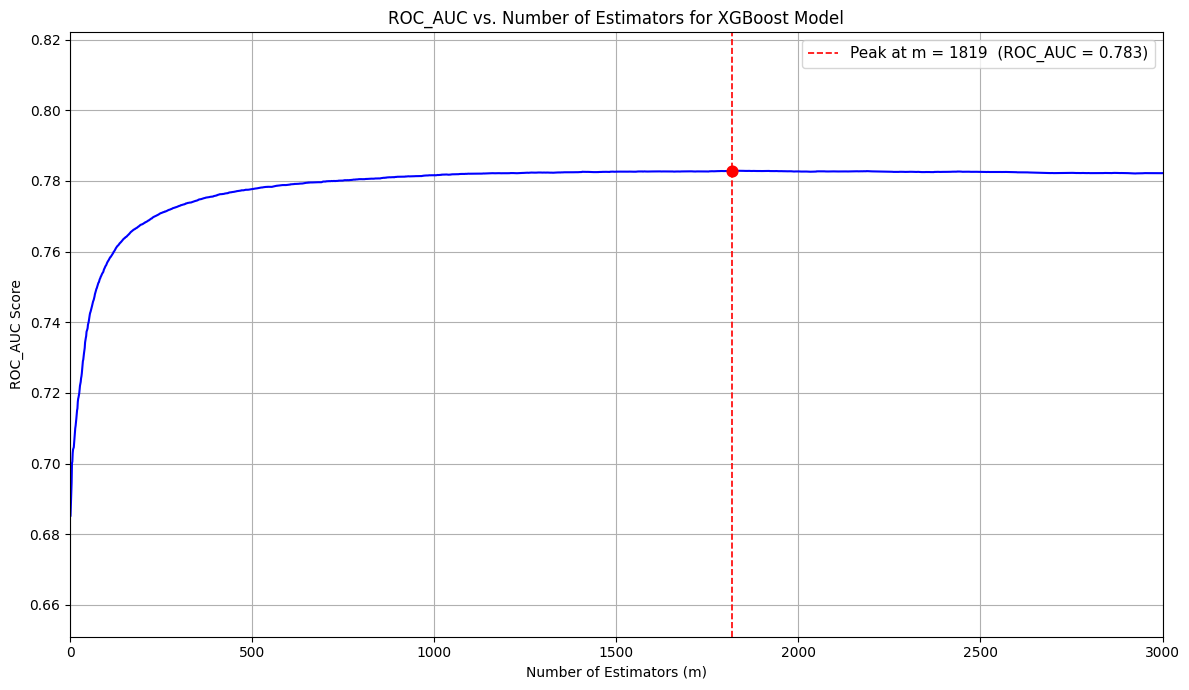

In [12]:
import matplotlib.pyplot as plt
import numpy as np

roc_auc_scores = []
estimators_count = []

booster = xgb_model.get_booster()
dtest = xgb.DMatrix(X_test)

for m in range(1, xgb_model.n_estimators + 1):
    y_pred_proba_stage = booster.predict(dtest, iteration_range=(0, m))
    roc_auc = roc_auc_score(y_test, y_pred_proba_stage)

    roc_auc_scores.append(roc_auc)
    estimators_count.append(m)

best_m_xgb = estimators_count[np.argmax(roc_auc_scores)]
best_auc = max(roc_auc_scores)

plt.figure(figsize=(12, 7))
plt.plot(estimators_count, roc_auc_scores, linestyle='-', linewidth=1.5, color='blue')
plt.axvline(x=best_m_xgb, color='red', linestyle='--', linewidth=1.2,
            label=f'Peak at m = {best_m_xgb}  (ROC_AUC = {best_auc:.3f})')
plt.scatter([best_m_xgb], [best_auc], color='red', zorder=5, s=60)
plt.legend(fontsize=11)

plt.title('ROC_AUC vs. Number of Estimators for XGBoost Model')
plt.xlabel('Number of Estimators (m)')
plt.ylabel('ROC_AUC Score')
plt.grid(True)

plt.xlim(0, xgb_model.n_estimators)
plt.ylim(
    min(roc_auc_scores) * 0.95,
    max(roc_auc_scores) * 1.05
)

plt.tight_layout()
plt.savefig("roc_auc_vs_estimators_xgb.pdf", bbox_inches="tight")
plt.show()

# Plotting ROC_AUC Score for increasing numbers of boosting iterations.
# The curve can be used to identify the estimator count that maximizes
# predictive performance on the test set and to assess potential overfitting
# at later boosting stages.

In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gbm_model = GradientBoostingClassifier(
    n_estimators=2000,
    max_depth=3,
    learning_rate=0.05,
    random_state=87
)

gbm_model.fit(X_train, y_train, sample_weight=weights)

y_pred_proba_gbm = gbm_model.predict_proba(X_test)[:, 1]
y_pred_gbm = gbm_model.predict(X_test)

print("ROC_AUC:", roc_auc_score(y_test, y_pred_proba_gbm))
print(classification_report(y_test, y_pred_gbm))

# GBM model trained with the optimal hyperparameters of XGBoost, following the hypothesis
# that the models are structurally similar
# n_estimators is set to 2000 to reduce training time: XGBoost peaks at ~1800, and since GBM
# does not apply L2 regularization, it likely needs even fewer estimators
# Output shows a very similar result to XGBoost; the improvement is marginal, and recall and precision are similar too

ROC_AUC: 0.7830819450469321
              precision    recall  f1-score   support

           0       0.96      0.75      0.84     56538
           1       0.19      0.67      0.30      4965

    accuracy                           0.74     61503
   macro avg       0.58      0.71      0.57     61503
weighted avg       0.90      0.74      0.80     61503



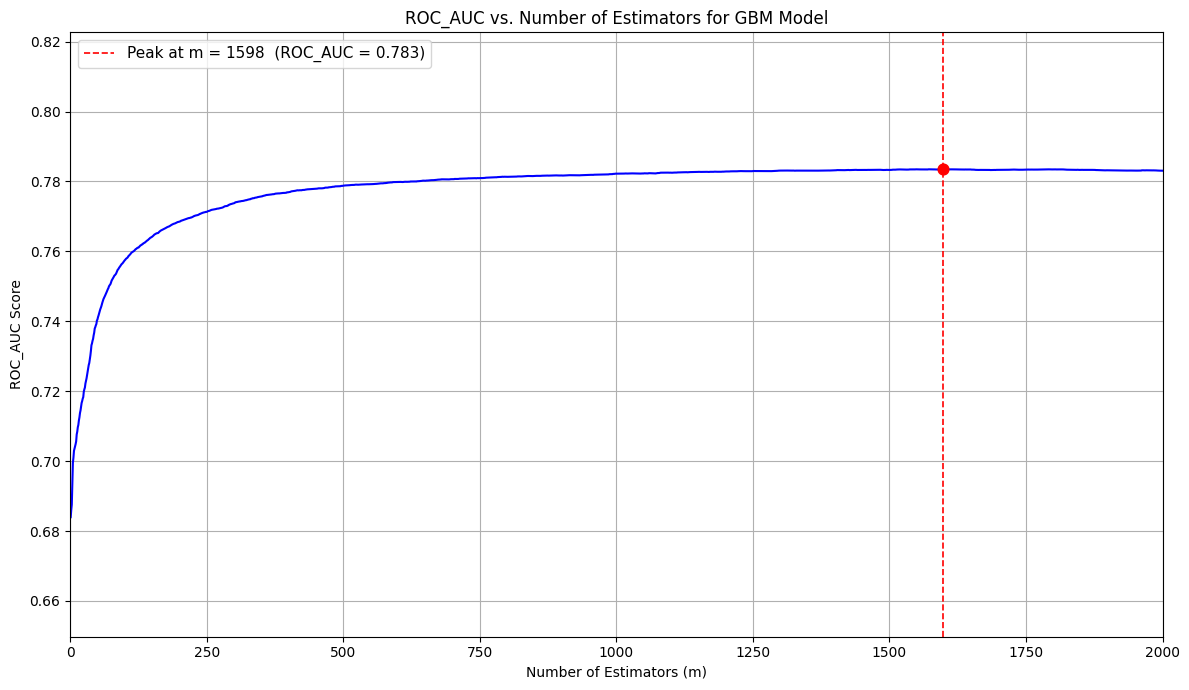

In [14]:
roc_auc_scores = []
estimators_count = []

for m, y_pred_proba_stage in enumerate(gbm_model.staged_predict_proba(X_test), start=1):
    roc_auc = roc_auc_score(y_test, y_pred_proba_stage[:, 1])
    roc_auc_scores.append(roc_auc)
    estimators_count.append(m)

best_m_gbm = estimators_count[np.argmax(roc_auc_scores)]
best_auc = max(roc_auc_scores)

plt.figure(figsize=(12, 7))
plt.plot(estimators_count, roc_auc_scores, linestyle='-', linewidth=1.5, color='blue')
plt.axvline(x=best_m_gbm, color='red', linestyle='--', linewidth=1.2,
            label=f'Peak at m = {best_m_gbm}  (ROC_AUC = {best_auc:.3f})')
plt.scatter([best_m_gbm], [best_auc], color='red', zorder=5, s=60)
plt.legend(fontsize=11)

plt.title('ROC_AUC vs. Number of Estimators for GBM Model')
plt.xlabel('Number of Estimators (m)')
plt.ylabel('ROC_AUC Score')
plt.grid(True)

plt.xlim(0, gbm_model.n_estimators)
plt.ylim(min(roc_auc_scores) * 0.95, max(roc_auc_scores) * 1.05)

plt.tight_layout()
plt.savefig("roc_auc_vs_estimators_gbm.pdf", bbox_inches="tight")
plt.show()

# Plotting ROC_AUC score against the number of estimators
# Output shows a peak in ROC_AUC at around 1600 estimators
# However, the first three decimals of the ROC_AUC do not change, so n_estimators=2000 is practically optimal
# GBM peaks at a lower number of estimators than XGBoost, which makes sense: XGBoost's L2 regularization
# shrinks leaf values and therefore learns more slowly

In [ ]:
from sklearn.metrics import RocCurveDisplay

models = {
    'Logistic Regression': (lr_model, X_test_scaled),
    'GBM': (gbm_model, X_test),
    'XGBoost': (xgb_model, X_test)
}

fig, ax = plt.subplots(figsize=(10, 8))

for name, (model, X_test_data) in models.items():
    y_pred_proba = model.predict_proba(X_test_data)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    label = f"{name} (AUC = {auc:.3f})"
    RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=ax, name=label)

plt.title('ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(alpha=0.4)
plt.legend(loc='lower right')
plt.savefig('roc_curves_all_models.pdf', bbox_inches='tight')
plt.show()

# Plotting the ROC curves for all models
# Output shows the expected outcome: the AUC values for GBM and XGBoost are higher than for Logistic Regression

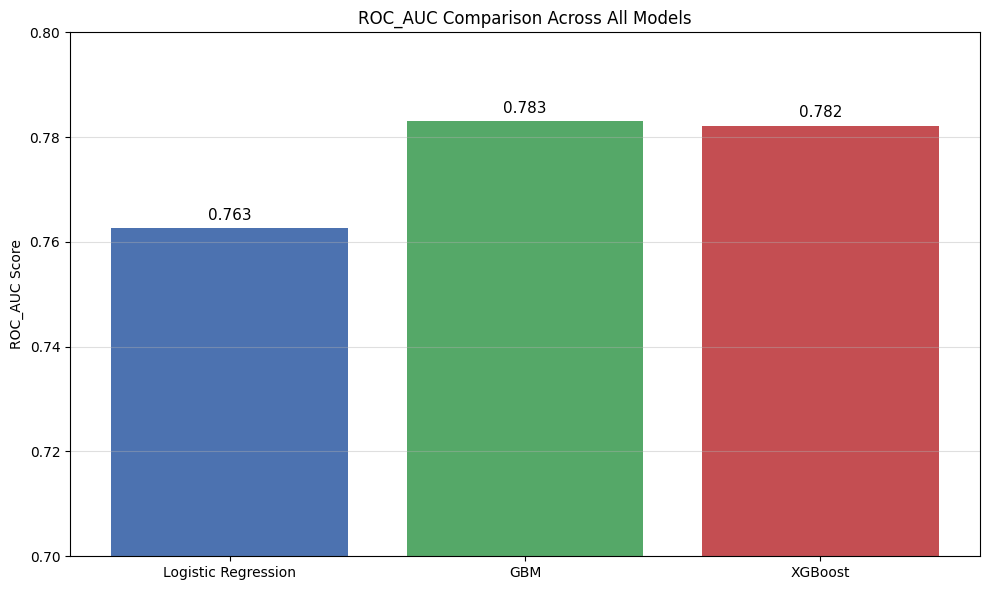

In [16]:
names, aucs = [], []
for name, (model, X_test_data) in models.items():
    proba = model.predict_proba(X_test_data)[:, 1]
    names.append(name)
    aucs.append(roc_auc_score(y_test, proba))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(names, aucs,
              color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_ylim(0.70, 0.80)
ax.set_ylabel('ROC_AUC Score')
ax.set_title('ROC_AUC Comparison Across All Models')
ax.grid(axis='y', alpha=0.4)
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{auc:.3f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('roc_auc_barplot.pdf', bbox_inches='tight')
plt.show()

# Barplot comparing the ROC_AUC of all three models